In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/my_data (1).csv")
df.drop(columns=['name'],inplace=True)

In [15]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        905 non-null    object 
 1   gender      994 non-null    object 
 2   profession  921 non-null    object 
 3   age         982 non-null    float64
 4   cgpa        962 non-null    float64
 5   placed      1100 non-null   int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 51.7+ KB


,city,gender,profession,age,cgpa,placed
0,NaN,female,phd,28.0,5.94,1
1,asgard,NaN,bachelor,50.0,8.55,0
2,NaN,female,masters,18.0,5.56,0
3,NaN,male,bachelor,25.0,8.57,1
4,NaN,male,bachelor,19.0,8.76,1


Dari deskripsi data tersebut, jumlah data pada file sebanyak 1100 baris dengan jumlah variabel ada 7 kolom. Untuk tipe data yang termasuk kategorikal yaitu kolom 'name', 'city', 'gender', 'profession'. Untuk tipe data numerik yaitu kolom 'age', dan 'cgpa'. Sedangkan kolom placed merupanak data biner.

In [16]:
df.isnull().sum()

,0
city,195
gender,106
profession,179
age,118
cgpa,138
placed,0


Ternyata hampir disemua kolom terdapat missing, sehingga akan dilakukan preprocessing.

In [19]:
# Hapus baris yang duplikat
df_clean = df.drop_duplicates()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1026 entries, 0 to 1098
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        846 non-null    object 
 1   gender      927 non-null    object 
 2   profession  857 non-null    object 
 3   age         917 non-null    float64
 4   cgpa        903 non-null    float64
 5   placed      1026 non-null   int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 56.1+ KB


Kemudian dilakukan penghapusan data duplikat, total data setelah penghapusan duplikat menjadi 1026 baris.

In [26]:
# Handling missing value
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].mean())
df_clean['cgpa'] = df_clean['cgpa'].fillna(df_clean['cgpa'].mean())

/tmp/ipykernel_1494/3631651256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['age'] = df_clean['age'].fillna(df_clean['age'].mean())
/tmp/ipykernel_1494/3631651256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['cgpa'] = df_clean['cgpa'].fillna(df_clean['cgpa'].mean())


Untuk meng-handling missing value pada kolom yang bertipe numerik, dilakukan dengan mengisi menggunakan mean karena agar tidak mengurangi jumlah observasi.

In [27]:
# Handling missing value
df_clean['city'] = df_clean['city'].fillna(df_clean['city'].mode()[0])
df_clean['gender'] = df_clean['gender'].fillna(df_clean['gender'].mode()[0])
df_clean['profession'] = df_clean['profession'].fillna(df_clean['profession'].mode()[0])

/tmp/ipykernel_1494/3727666939.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['city'] = df_clean['city'].fillna(df_clean['city'].mode()[0])
/tmp/ipykernel_1494/3727666939.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['gender'] = df_clean['gender'].fillna(df_clean['gender'].mode()[0])
/tmp/ipykernel_1494/3727666939.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

Untuk meng-handling missing value pada kolom yang bertipe kategorikal, dilakukan dengan mengisi menggunakan modus atau nilai paling sering muncul.

In [28]:
df_clean.isnull().sum()

,0
city,0
gender,0
profession,0
age,0
cgpa,0
placed,0


Setelah dilakukan pengisian missing value, sudah tidak ada lagi missing value pada semua kolom.

In [29]:
df_clean.to_csv('data_bersih.csv', index=False)

In [68]:
dfc = pd.read_csv("/content/data_bersih.csv")
dfc.head()

,city,gender,profession,age,cgpa,placed
0,wakanda,female,phd,28.0,5.94,1
1,asgard,male,bachelor,50.0,8.55,0
2,wakanda,female,masters,18.0,5.56,0
3,wakanda,male,bachelor,25.0,8.57,1
4,wakanda,male,bachelor,19.0,8.76,1


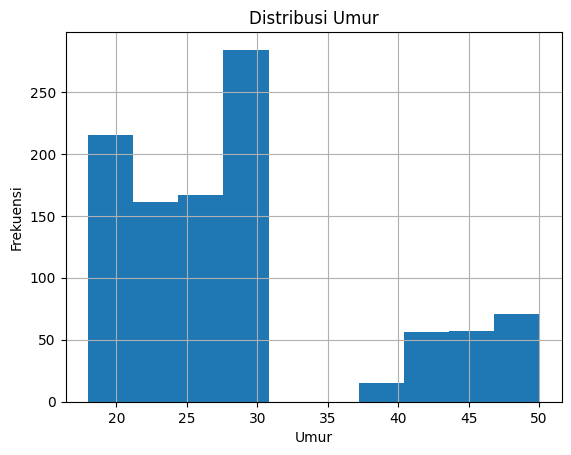

In [51]:
plt.figure()
dfc['age'].hist()
plt.title('Distribusi Umur')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

Grafik menunjukkan bahwa mayoritas responden berada pada rentang usia sekitar 20 hingga 30 tahun, yang mengindikasikan dominasi kelompok usia muda atau fresh graduate. Terdapat juga sebagian kecil responden dengan usia lebih tinggi (sekitar 40–50 tahun), yang bisa dianggap sebagai outlier atau kelompok non-tradisional. Pola distribusi ini menunjukkan bahwa dataset didominasi oleh individu pada usia produktif awal yang sedang memasuki dunia kerja.

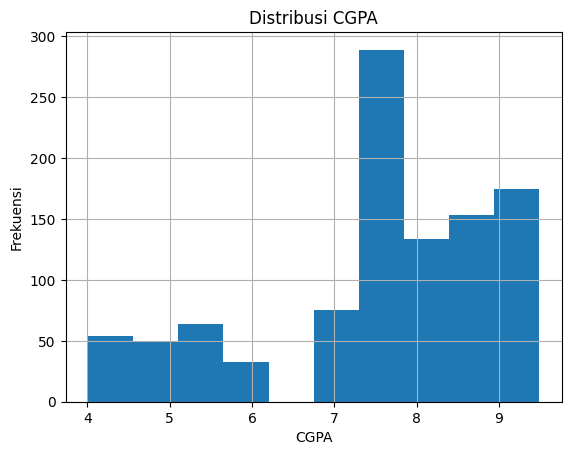

In [52]:
plt.figure()
dfc['cgpa'].hist()
plt.title('Distribusi CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frekuensi')
plt.show()

Distribusi CGPA terlihat terkonsentrasi pada rentang nilai menengah hingga tinggi, khususnya sekitar 7 hingga 9. Hal ini menunjukkan bahwa sebagian besar mahasiswa memiliki performa akademik yang cukup baik. Namun, masih terdapat sejumlah kecil mahasiswa dengan CGPA rendah (sekitar 4–6), yang dapat menjadi pembanding dalam analisis pengaruh akademik terhadap peluang kerja.

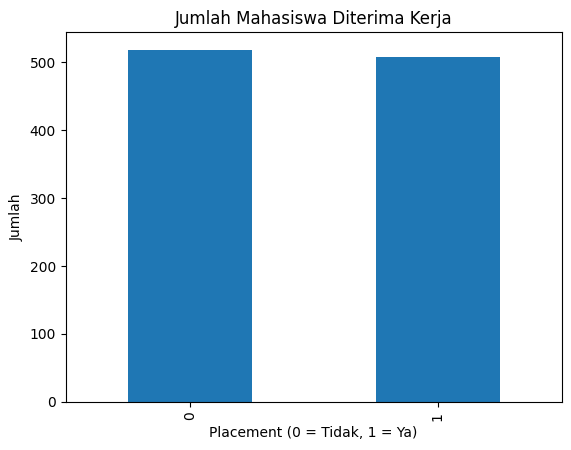

In [53]:
plt.figure()
dfc['placed'].value_counts().plot(kind='bar')
plt.title('Jumlah Mahasiswa Diterima Kerja')
plt.xlabel('Placement (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()

Grafik menunjukkan bahwa jumlah mahasiswa yang diterima kerja (placed = 1) dan yang tidak diterima (placed = 0) relatif seimbang. Hal ini menandakan bahwa dataset tidak terlalu bias terhadap salah satu kelas.

In [57]:
# CGPA vs PLACEMENT

avg_cgpa = dfc.groupby('placed')['cgpa'].mean()
print("\nRata-rata CGPA:\n", avg_cgpa)


Rata-rata CGPA:
 placed
0    7.561875
1    7.568221
Name: cgpa, dtype: float64


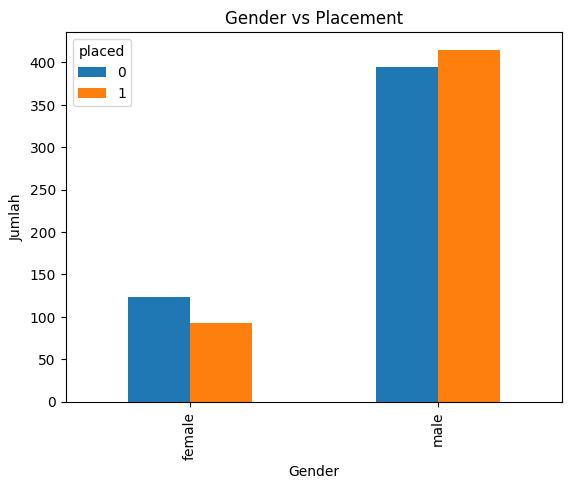


Tabel Gender vs Placement:
 placed    0    1
gender          
female  123   93
male    395  415


In [59]:
# GENDER vs PLACEMENT

gender_placement = pd.crosstab(dfc['gender'], dfc['placed'])

gender_placement.plot(kind='bar')
plt.title('Gender vs Placement')
plt.xlabel('Gender')
plt.ylabel('Jumlah')
plt.show()

print("\nTabel Gender vs Placement:\n", gender_placement)

Grafik memperlihatkan bahwa jumlah responden laki-laki lebih banyak dibandingkan perempuan dalam dataset. Dari sisi placement, terlihat bahwa baik laki-laki maupun perempuan memiliki distribusi yang relatif mirip antara yang diterima dan tidak diterima kerja. Hal ini mengindikasikan bahwa gender tidak menunjukkan perbedaan yang terlalu signifikan terhadap peluang kerja dalam dataset ini.

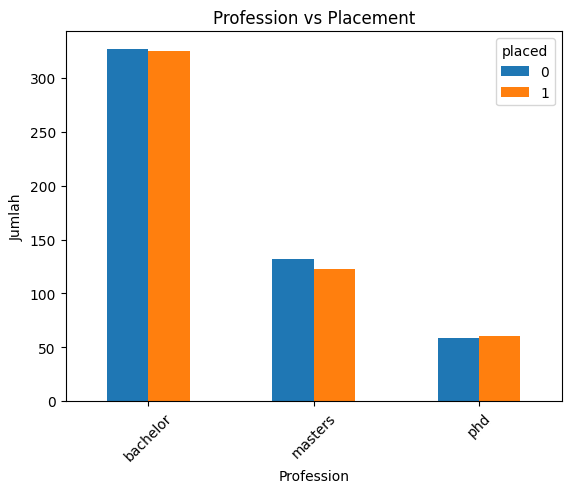


Tabel Profession vs Placement:
 placed        0    1
profession          
bachelor    327  325
masters     132  123
phd          59   60


In [60]:
# PROFESSION vs PLACEMENT

prof_placement = pd.crosstab(dfc['profession'], dfc['placed'])

prof_placement.plot(kind='bar')
plt.title('Profession vs Placement')
plt.xlabel('Profession')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

print("\nTabel Profession vs Placement:\n", prof_placement)

Berdasarkan tabel tersebut, jumlah mahasiswa dengan tingkat pendidikan bachelor merupakan yang paling dominan, baik pada kategori tidak diterima kerja maupun diterima kerja. Pada kelompok ini, jumlah yang diterima kerja (325) hampir sama dengan yang tidak diterima (327), menunjukkan peluang kerja yang relatif seimbang.

Untuk tingkat pendidikan masters, jumlah mahasiswa yang tidak diterima kerja (132) sedikit lebih tinggi dibandingkan yang diterima (123), namun perbedaannya tidak terlalu signifikan. Hal ini menunjukkan bahwa lulusan masters tidak memiliki keunggulan yang mencolok dibandingkan bachelor dalam hal peluang kerja pada dataset ini.

Sementara itu, pada tingkat phd, jumlah mahasiswa yang diterima kerja (60) sedikit lebih tinggi dibandingkan yang tidak diterima (59), meskipun selisihnya sangat kecil. Secara keseluruhan, hasil ini mengindikasikan bahwa tingkat pendidikan tidak menunjukkan perbedaan yang signifikan terhadap peluang kerja, karena distribusi antara diterima dan tidak diterima relatif seimbang di setiap kategori.